# CEBRA Best Practices with 🐟<b>i</b><span style="color: #3C92ED;">Tuna</span>

*This notebook is based on the ["Best Practices for Training CEBRA models" notebook](https://cebra.ai/docs/demo_notebooks/CEBRA_best_practices.html)*

This demo shows a complete workflow for training CEBRA models with consistency evaluation using iTuna. We cover:

1. Setting up a CEBRA model
2. Loading neural data
3. Train/validation splits
4. Consistency evaluation with `ConsistencyEnsemble`
5. Visualizing and interpreting results
6. Grid search for hyperparameters

## Prerequisites

```bash
pip install ituna cebra[datasets,integrations]
```

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from cebra import CEBRA
import cebra.datasets

import ituna
from ituna import ConsistencyEnsemble, metrics

## 🐟<b>i</b><span style="color: #3C92ED;">Tuna</span> Caching Magic

Re-training models every time we re-run the notebook is annoying, especially if we train lots of models for consitency analysis. 

Therefore with 🐟<b>i</b><span style="color: #3C92ED;">Tuna</span> we make it as easy as possible to automatically cache every model training. 

- For a full walkthrough of caching, distributed execution, and backend routing, see: `docs/tutorials/backends.ipynb`
- If you want to cache *standalone* sklearn estimators (outside `ConsistencyEnsemble`), see: `docs/guides/sklearn_caching.ipynb`


In [15]:
ituna.config.set(
    DEFAULT_BACKEND="disk_cache",
)
print(ituna.config.get_config())

{'DEFAULT_BACKEND': 'disk_cache', 'BACKEND_KWARGS': {}, 'BACKEND_ROUTES': {}, 'CACHE_DIR': 'backend_store', 'FILE_LOCK_TIMEOUT': 30}


## 1. Set up a CEBRA Model

CEBRA is a self-supervised representation learning method for neural data. It learns embeddings that capture the temporal structure of neural activity.

CEBRA models are identifiable up to an **affine transformation**, so we use `metrics.Linear()` (which includes the intercept) as our indeterminacy class.

In [16]:
# Define a CEBRA-Time model
cebra_model = CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.12,
    max_iterations=500,
    conditional="time",
    output_dimension=3,
    distance="cosine",
    device="cuda_if_available",
    verbose=True,
    time_offsets=10,
)

## 2. Load the Data

We'll use the rat hippocampus dataset from CEBRA's built-in datasets. This contains neural recordings from hippocampus during spatial navigation.

In [17]:
# Load hippocampus dataset
hippocampus = cebra.datasets.init("rat-hippocampus-single-achilles")

neural_data = hippocampus.neural.numpy()
position_labels = hippocampus.continuous_index.numpy()

print(f"Neural data shape: {neural_data.shape}")
print(f"Position labels shape: {position_labels.shape}")

Neural data shape: (10178, 120)
Position labels shape: (10178, 3)


/home/hgf_hmgu/hgf_sfs7789/miniconda3/envs/ituna-dev/lib/python3.12/pickle.py:1632: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  stack[-1] = func(*args)


## 3. Create Train/Validation Split

For proper evaluation, we split the data temporally into training and validation sets.

In [18]:
# Time-based split (80% train, 20% validation)
split_idx = int(len(neural_data) * 0.8)

train_data = neural_data[:split_idx]
val_data = neural_data[split_idx:]

train_labels = position_labels[:split_idx]
val_labels = position_labels[split_idx:]

print(f"Train data: {train_data.shape}")
print(f"Validation data: {val_data.shape}")

Train data: (8142, 120)
Validation data: (2036, 120)


## 4. Fit with ConsistencyEnsemble

Now we wrap the CEBRA model in a `ConsistencyEnsemble` to train multiple instances and evaluate consistency.

In [19]:
# Create ConsistencyEnsemble with Linear indeterminacy (for CEBRA)
ensemble = ConsistencyEnsemble(
    estimator=cebra_model,
    consistency_transform=metrics.PairwiseConsistency(
        indeterminacy=metrics.Linear(),  # CEBRA is identifiable up to linear transform
        symmetric=False,
        include_diagonal=True,
    ),
    random_states=5,  # Train 5 models
)

# Fit on training data
ensemble.fit(train_data)

,estimator,CEBRA(batch_s... verbose=True)
,consistency_transform,PairwiseConsi...nacy=Linear())
,random_states,5
,copy_X,True
,n_jobs,None
,positive,False
,model_architecture,'offset10-model'
,device,'cuda_if_available'
,criterion,'infonce'
,distance,'cosine'
,conditional,'time'


In [20]:
# Evaluate consistency
train_score = ensemble.score(train_data)
print(f"Train consistency score: {train_score:.4f}")

# Also check on validation data
val_score = ensemble.score(val_data)
print(f"Validation consistency score: {val_score:.4f}")

Train consistency score: 0.8917


Validation consistency score: 0.8403


## 5. Visualize Embeddings

Let's visualize the learned embeddings colored by position.

In [21]:
# Get aligned embeddings
train_embeddings = ensemble.transform(train_data)
val_embeddings = ensemble.transform(val_data)

print(f"Train embedding shape: {train_embeddings.shape}")
print(f"Validation embedding shape: {val_embeddings.shape}")

Train embedding shape: (8142, 3)
Validation embedding shape: (2036, 3)


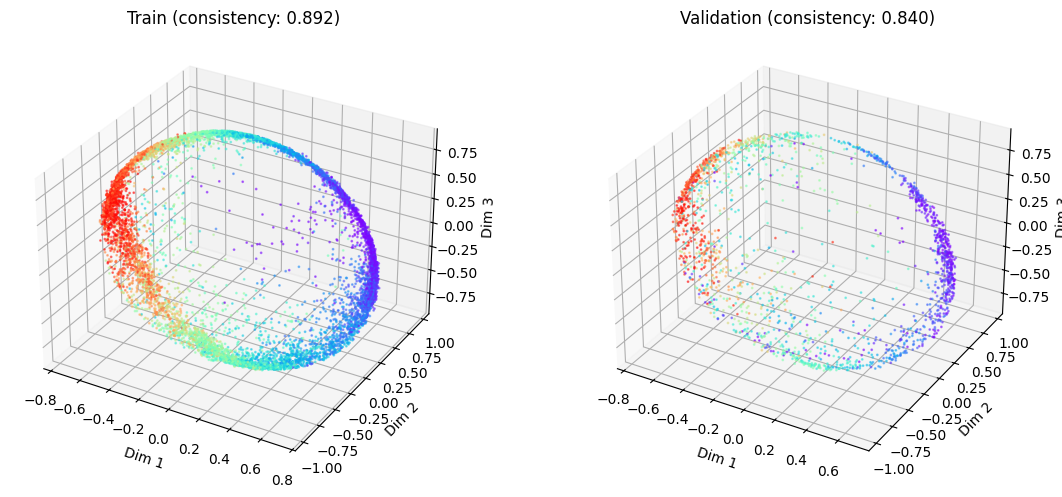

In [22]:
# Plot 3D embeddings
fig = plt.figure(figsize=(12, 5))

# Train embeddings
ax1 = fig.add_subplot(121, projection="3d")
scatter1 = ax1.scatter(
    train_embeddings[:, 0],
    train_embeddings[:, 1],
    train_embeddings[:, 2],
    c=train_labels[:, 0],
    cmap="rainbow",
    s=1,
    alpha=0.5,
)
ax1.set_title(f"Train (consistency: {train_score:.3f})")
ax1.set_xlabel("Dim 1")
ax1.set_ylabel("Dim 2")
ax1.set_zlabel("Dim 3")

# Validation embeddings
ax2 = fig.add_subplot(122, projection="3d")
scatter2 = ax2.scatter(
    val_embeddings[:, 0],
    val_embeddings[:, 1],
    val_embeddings[:, 2],
    c=val_labels[:, 0],
    cmap="rainbow",
    s=1,
    alpha=0.5,
)
ax2.set_title(f"Validation (consistency: {val_score:.3f})")
ax2.set_xlabel("Dim 1")
ax2.set_ylabel("Dim 2")
ax2.set_zlabel("Dim 3")

plt.tight_layout()
plt.show()

## 6. Analyze Pairwise Consistency

We can examine the consistency between individual model pairs.

In [23]:
# Get detailed pairwise scores
pairs, scores = train_embeddings.scores

print("Pairwise consistency scores:")
for (i, j), score in zip(pairs, scores):
    print(f"  Model {i} -> Model {j}: {score:.4f}")

print(f"\nMean pairwise score: {np.mean(scores):.4f}")
print(f"Std pairwise score: {np.std(scores):.4f}")

Pairwise consistency scores:
  Model 0 -> Model 0: 1.0000
  Model 0 -> Model 1: 0.9734
  Model 0 -> Model 2: 0.8756
  Model 0 -> Model 3: 0.8968
  Model 0 -> Model 4: 0.8630
  Model 1 -> Model 0: 0.9736
  Model 1 -> Model 1: 1.0000
  Model 1 -> Model 2: 0.8831
  Model 1 -> Model 3: 0.8951
  Model 1 -> Model 4: 0.8750
  Model 2 -> Model 0: 0.7756
  Model 2 -> Model 1: 0.7755
  Model 2 -> Model 2: 1.0000
  Model 2 -> Model 3: 0.9021
  Model 2 -> Model 4: 0.9247
  Model 3 -> Model 0: 0.7586
  Model 3 -> Model 1: 0.7514
  Model 3 -> Model 2: 0.8814
  Model 3 -> Model 3: 1.0000
  Model 3 -> Model 4: 0.8524
  Model 4 -> Model 0: 0.8088
  Model 4 -> Model 1: 0.8042
  Model 4 -> Model 2: 0.9299
  Model 4 -> Model 3: 0.8925
  Model 4 -> Model 4: 1.0000

Mean pairwise score: 0.8917
Std pairwise score: 0.0792


## Summary

Key takeaways for CEBRA with iTuna:

1. **Use `metrics.Linear()` for CEBRA** - CEBRA embeddings are identifiable up to linear transformations
2. **Train multiple seeds** - Use `random_states=5` or more for robust consistency estimates
3. **Check both train and validation** - High consistency on both suggests stable representations
4. **Use caching for grid search** - Enable `disk_cache` backend to avoid re-training
5. **Consistency score > 0.9** - Generally indicates reliable, reproducible embeddings

For more examples, see:
- `ituna-experiments/cebra/` - Extended CEBRA experiments
- `iTune Reference.ipynb` - Comprehensive reference notebook